# **Offensive Speech: Detecting Toxic Tweets**
Trying to build models (RNN, LSTM, & GRU) that can accurately identify offensive language on Twitter

## Dataset Description
The dataset I used is about tweets labeled for hate speech detection. Each tweet is classified into one of three categories:

- **Class 0 — Hate Speech**
- **Class 1 — Offensive Language**
- **Class 2 — Neither**

## Columns Description


- `count`: Total number of annotators for the tweet  
- `hate_speech_count`: Number of annotators labeling the tweet as hate speech  
- `offensive_language_count`: Number of annotators labeling it as offensive language  
- `neither_count`: Number of annotators labeling it as neither  
- `tweet`: Original raw tweet text  
- `class`: Final assigned label (0, 1, or 2)  
- `tweet_clean`: Preprocessed version of the tweet used for modeling  

## Objective

The aim is to train sequence models (RNN, LSTM, and GRU) to:

- Learn contextual representations of tweets using embeddings.
- Capture sequential dependencies in text.
- Classify each tweet into one of the three predefined categories.

# Importing Necessary Libraries

In [ ]:
import os
import re
import string
import numpy as np
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Mounting to Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Loading & EDA


In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/Datasets/NLP/train.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/Datasets/NLP/test.csv')

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (19826, 6)
Test shape : (4957, 5)


In [ ]:
train_df.head()

,count,hate_speech_count,offensive_language_count,neither_count,tweet,class
0,3,2,0,1,RT @FunSizedYogi: @TheBlackVoice well how else...,0
1,3,0,0,3,Funny thing is....it's not just the people doi...,2
2,3,0,3,0,"RT @winkSOSA: ""@AintShitSweet__: ""@Rakwon_OGOD...",1
3,3,0,3,0,@Jbrendaro30 @ZGabrail @ramsin1995 @GabeEli8 @...,1
4,6,0,6,0,S/o that real bitch,1


In [ ]:
test_df.head()

,count,hate_speech_count,offensive_language_count,neither_count,tweet
0,3,0,3,0,934 8616\ni got a missed call from yo bitch
1,3,0,3,0,RT @KINGTUNCHI_: Fucking with a bad bitch you ...
2,3,0,1,2,RT @eanahS__: @1inkkofrosess lol my credit ain...
3,3,0,3,0,RT @Maxin_Betha Wipe the cum out of them faggo...
4,3,1,2,0,Niggas cheat on they bitch and don't expect no...


In [ ]:
print("Train columns:", train_df.columns.tolist())
print("\nMissing values (train):\n", train_df.isna().sum())
print("\nMissing values (test):\n", test_df.isna().sum())

Train columns: ['count', 'hate_speech_count', 'offensive_language_count', 'neither_count', 'tweet', 'class']

Missing values (train):
 count                       0
hate_speech_count           0
offensive_language_count    0
neither_count               0
tweet                       0
class                       0
dtype: int64

Missing values (test):
 count                       0
hate_speech_count           0
offensive_language_count    0
neither_count               0
tweet                       0
dtype: int64



Class counts:
 class
0     1140
1    15358
2     3328
Name: count, dtype: int64


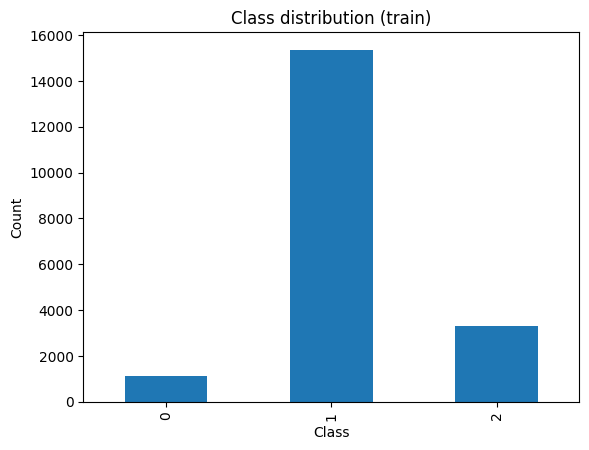

In [ ]:
# Class distribution
if "class" in train_df.columns:
    class_counts = train_df["class"].value_counts().sort_index()
    print("\nClass counts:\n", class_counts)

    plt.figure()
    class_counts.plot(kind="bar")
    plt.title("Class distribution (train)")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

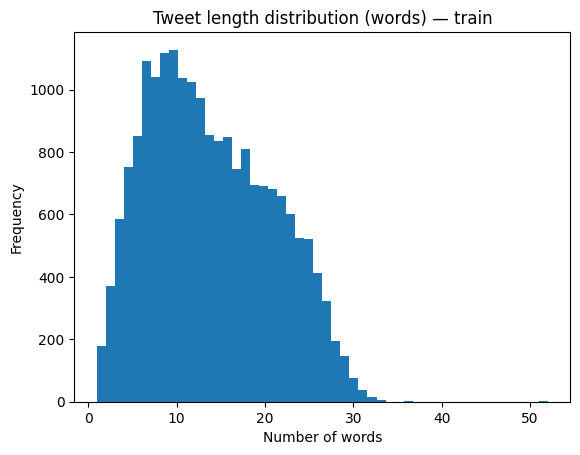

In [ ]:
# Tweet length stats
train_lengths = train_df["tweet"].astype(str).apply(lambda x: len(x.split()))
plt.figure()
plt.hist(train_lengths, bins=50)
plt.title("Tweet length distribution (words) — train")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

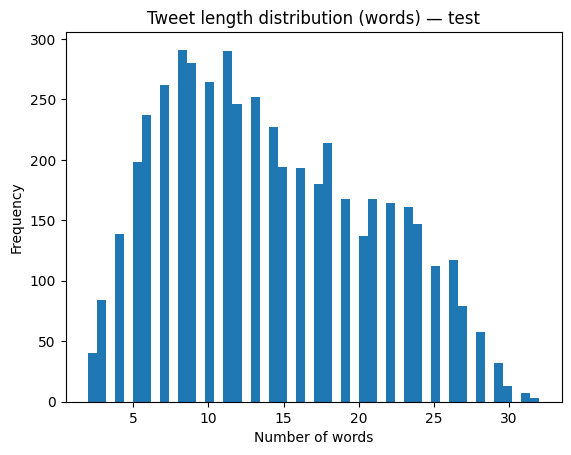

In [ ]:
# Tweet length stats
test_lengths = test_df["tweet"].astype(str).apply(lambda x: len(x.split()))
plt.figure()
plt.hist(test_lengths, bins=50)
plt.title("Tweet length distribution (words) — test")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("\nTweet length (words) summary for the train set:\n", train_lengths.describe())


Tweet length (words) summary for the train set:
 count    19826.000000
mean        14.133209
std          6.830165
min          1.000000
25%          9.000000
50%         13.000000
75%         19.000000
max         52.000000
Name: tweet, dtype: float64


In [ ]:
print("\nTweet length (words) summary for the test set:\n", test_lengths.describe())


Tweet length (words) summary for the test set:
 count    4957.000000
mean       14.052249
std         6.807237
min         2.000000
25%         8.000000
50%        13.000000
75%        19.000000
max        32.000000
Name: tweet, dtype: float64


# Preprocessing
In this step, I tried to clean tweets to remove noise and standardize the text before modeling, and this was via:

- Converting text to lowercase  
- Removing URLs, mentions, retweet tokens, and extra Twitter artifacts  
- Removing punctuation and extra whitespace  
- Expanding common abbreviations (e.g., *"u" → "you"*, *"idk" → "i do not know"*)  

This helps reduce vocabulary inconsistencies and improves the quality of input fed into the sequence models. The cleaned text is stored in a column I named **"tweet_clean"**.

In [ ]:
# Small, safe abbreviation normalization
ABBREV_MAP = {
    "u": "you",
    "ur": "your",
    "r": "are",
    "idk": "i do not know",
    "idc": "i do not care",
    "bc": "because",
    "cuz": "because",
    "btw": "by the way",
    "imo": "in my opinion",
    "tbh": "to be honest",
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "rn": "right now",
    "ppl": "people",
    "thx": "thanks",
    "tysm": "thank you so much"
}

# Extra twitter artifacts to drop
CUSTOM_DROP_TOKENS = {"amp", "via"}

def clean_tweet(text) -> str:
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove @mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove RT token
    text = re.sub(r"\brt\b", " ", text)

    # Keep hashtag words, remove only '#'
    text = text.replace("#", "")

    # Normalize common abbreviations (word-level)
    words = text.split()
    words = [ABBREV_MAP.get(w, w) for w in words]
    words = [w for w in words if w not in CUSTOM_DROP_TOKENS]
    text = " ".join(words)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Collapse repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply to train/test dataframes
train_df["tweet_clean"] = train_df["tweet"].apply(clean_tweet)
test_df["tweet_clean"]  = test_df["tweet"].apply(clean_tweet)

# Quick check
train_df[["tweet", "tweet_clean"]].head()

,tweet,tweet_clean
0,RT @FunSizedYogi: @TheBlackVoice well how else...,well how else will white people get us to forg...
1,Funny thing is....it's not just the people doi...,funny thing isits not just the people doing it...
2,"RT @winkSOSA: ""@AintShitSweet__: ""@Rakwon_OGOD...",nigga messed with the wrong bitch 128557128514...
3,@Jbrendaro30 @ZGabrail @ramsin1995 @GabeEli8 @...,bitch ass nigggaaa
4,S/o that real bitch,so that real bitch


# Word cloud per class (extra EDA)

For extra EDA, a word cloud was generated for each class to visualize the most 150 frequent words in the cleaned tweets.

This step helps:
- Identify dominant terms per class  
- Understand linguistic differences between categories  
- Gain intuition about class-specific vocabulary patterns  

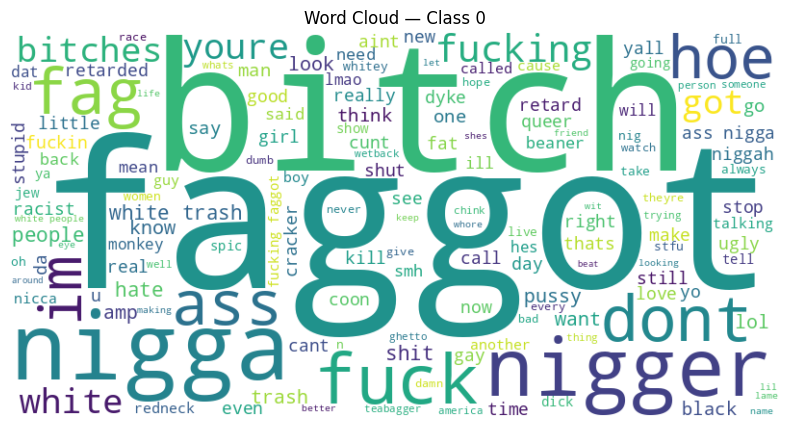

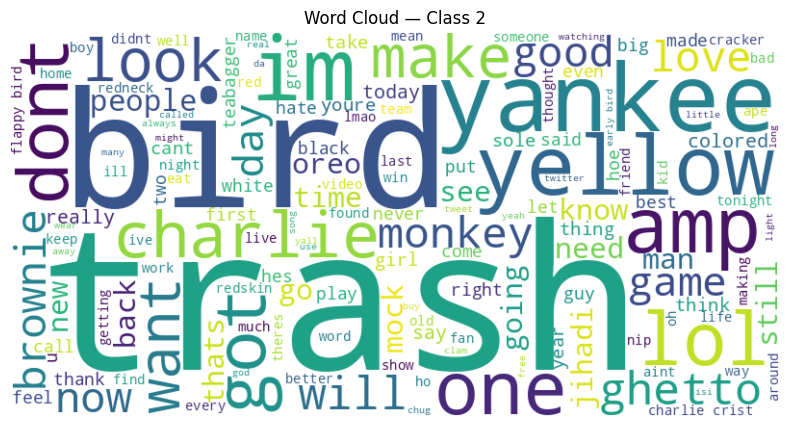

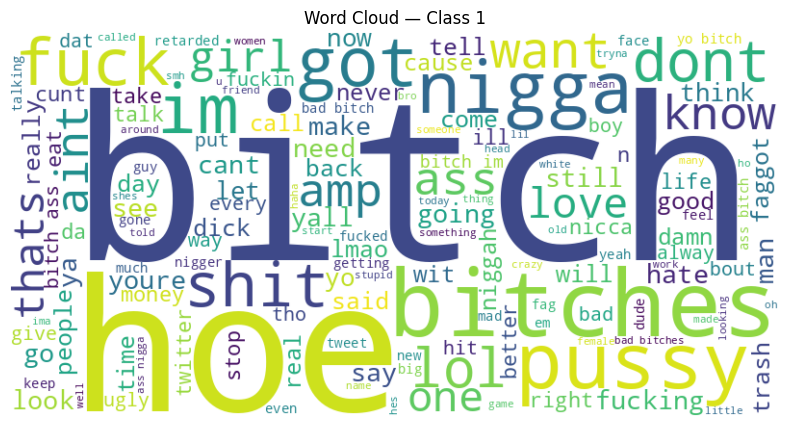

In [ ]:
classes = train_df["class"].unique()

for c in classes:
    text = " ".join(train_df[train_df["class"] == c]["tweet_clean"])

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=150
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud — Class {c}")
    plt.show()

# Train/Validation Split
I took **20**% from data for **Validation**, and kept the rest **80**% for **Training**

In [ ]:
X = train_df["tweet_clean"].values
y = train_df["class"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Validation size  :", len(X_val))

Train size: 15860
Validation size  : 3966


# Tokenization + Padding

In this step, cleaned tweets were converted to fixed-size numerical representations suitable for RNN, LSTM, and GRU models.

- The tokenizer keeps only the top 20,000 most frequent words (`VOCAB_SIZE`) and replaces unseen words with `<OOV>`.
- Each tweet is converted into a sequence of word indices (these indices are given based on their  rank of frequency)
- Sequences are padded or truncated to a fixed length of 50 tokens (`MAX_LEN`) to ensure uniform input shape for the models.

In [ ]:
#  Tokenization + Padding
VOCAB_SIZE = 20000
MAX_LEN    = 50
OOV_TOKEN  = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)  #only keep 20000 frequent words & replace oov tokens not in 20000
tokenizer.fit_on_texts(X_train)

def texts_to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_pad = texts_to_padded(X_train)
X_val_pad   = texts_to_padded(X_val)
X_test_pad  = texts_to_padded(test_df["tweet_clean"].values)

print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape  :", X_val_pad.shape)
print("X_test_pad shape :", X_test_pad.shape)

NUM_CLASSES = len(np.unique(y))
print("NUM_CLASSES:", NUM_CLASSES)

X_train_pad shape: (15860, 50)
X_val_pad shape  : (3966, 50)
X_test_pad shape : (4957, 50)
NUM_CLASSES: 3


# Model Building Function

##  Model Architecture (RNN / LSTM / GRU)

The model follows a sequence classification architecture where only the recurrent layer changes (RNN, LSTM, or GRU) for fair comparison.

### Input Layer
- Receives padded sequences of length 50.
- Ensures fixed-size numerical input for the network.

### Embedding Layer (I trained it from scratch; you can use pretrained embeddings like Word2Vec or GloVe)
- Converts each word index into a 128-dimensional trainable vector.
- Learns semantic word representations during training.

### Recurrent Layer (RNN / LSTM / GRU)
- Processes the sequence of word embeddings.
- Captures contextual and sequential dependencies.

### Dense (64, ReLU)
- Learns higher-level features from the sequence representation.
- Adds non-linearity for better classification capacity.

### Dropout
- Randomly deactivates neurons during training.
- Reduces overfitting and improves generalization.

### Output Layer (Softmax)
- Produces probability distribution over the 3 classes.
- Used with `sparse_categorical_crossentropy` for multi-class classification.


## Optimization & Regularization

- **Adam Optimizer (lr = 3e-4)**: Stable and adaptive gradient optimization.
- **Gradient Clipping (clipnorm=1.0)**: Prevents **exploding gradients** in recurrent networks.
- **EarlyStopping**: Stops training when validation loss stops improving.
- **ReduceLROnPlateau**: Reduces learning rate when training plateaus to improve convergence. In other words, if the validation loss stops improving for a few epochs, the learning rate is reduced (multiplied by a factor; here of 0.5) so the model can make smaller, more precise updates and continue improving.

In [ ]:
def build_model(model_type: str,
                     vocab_size: int = VOCAB_SIZE,
                     max_len: int = MAX_LEN,
                     num_classes: int = NUM_CLASSES,
                     embed_dim: int = 128,
                     units: int = 128,
                     dropout: float = 0.3,
                     lr: float = 3e-4,
                     clipnorm: float = 1.0) -> tf.keras.Model:

    inputs = layers.Input(shape=(max_len,), name="input_ids")
    x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, name="embedding")(inputs)

    cell = model_type.upper()
    if cell == "RNN":
        x = layers.SimpleRNN(units, dropout=dropout, name="simple_rnn")(x)
    elif cell == "LSTM":
        x = layers.LSTM(units, dropout=dropout, recurrent_dropout=0.0, name="lstm")(x)
    elif cell == "GRU":
        x = layers.GRU(units, dropout=dropout, recurrent_dropout=0.0, name="gru")(x)
    else:
        raise ValueError("model_type must be 'RNN', 'LSTM', or 'GRU'")

    # Shared classification head
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    x = layers.Dropout(dropout, name="dropout_head")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name=f"{cell}_classifier")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
# Training callbacks
callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

# Model Evaluation Function

In [ ]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name="Model"):

    # Generate predictions - train
    train_probs = model.predict(X_train, verbose=0)
    train_pred = np.argmax(train_probs, axis=1)

    # Validation predictions
    val_probs = model.predict(X_val, verbose=0)
    val_pred = np.argmax(val_probs, axis=1)

    print(f"\n========== {model_name} ==========")

    print("\n--- TRAIN METRICS ---")
    print("Accuracy       :", accuracy_score(y_train, train_pred))
    print("Macro F1       :", f1_score(y_train, train_pred, average="macro"))
    # print("Weighted F1    :", f1_score(y_train, train_pred, average="weighted"))

    print("\n--- VALIDATION METRICS ---")
    print("Accuracy       :", accuracy_score(y_val, val_pred))
    print("Macro F1       :", f1_score(y_val, val_pred, average="macro"))
    # print("Weighted F1    :", f1_score(y_val, val_pred, average="weighted"))

    print("\nValidation Classification Report:\n")
    print(classification_report(y_val, val_pred))

    print("Validation Confusion Matrix:\n")
    #print(confusion_matrix(y_val, val_pred))
    # Confusion matrix plot
    cm = confusion_matrix(y_val, val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title(f"{model_name} — Confusion Matrix (Validation)")
    plt.show()

# Computing Class Weights to Handle Imbalance

Since the dataset is imbalanced, class weights were computed using the `"balanced"` option.

This assigns:
- Higher weights to minority classes  
- Lower weights to majority classes  

This is done to penalize mistakes on minority classes more heavily during training. This prevents the model from simply predicting the dominant class and improves fairness across all classes.

In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(5.796783625730995), 1: np.float64(0.43030007054099517), 2: np.float64(1.9859754570498371)}


# Training RNN

In [ ]:
rnn_model = build_model("RNN", lr=3e-4, dropout=0.2)
rnn_model.summary()

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Model: "RNN_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)          │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,347 (9.92 MB)

 Trainable params: 2,601,347 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.3747 - loss: 1.0892 - val_accuracy: 0.8144 - val_loss: 0.7058 - learning_rate: 3.0000e-04
Epoch 2/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7632 - loss: 0.7721 - val_accuracy: 0.8116 - val_loss: 0.5725 - learning_rate: 3.0000e-04
Epoch 3/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8052 - loss: 0.5634 - val_accuracy: 0.7965 - val_loss: 0.5701 - learning_rate: 3.0000e-04
Epoch 4/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8567 - loss: 0.4171 - val_accuracy: 0.7176 - val_loss: 0.7527 - learning_rate: 3.0000e-04
Epoch 5/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8929 - loss: 0.2995 - val_accuracy: 0.6793 - val_loss: 0.9342 - learning_rate: 3.0000e-04
Epoch 6/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9205 - loss: 0.2139 - val_accuracy: 0.7968 - val_loss: 0.6493 - learning_rate: 1.5000e-04
Epoch 7/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy

# RNN Evaluation


========== RNN ==========

--- TRAIN METRICS ---
Accuracy       : 0.9043505674653216
Macro F1       : 0.7937829203129856

--- VALIDATION METRICS ---
Accuracy       : 0.7965204236006052
Macro F1       : 0.6317681537719971

Validation Classification Report:

              precision    recall  f1-score   support

           0       0.17      0.44      0.25       228
           1       0.95      0.82      0.88      3072
           2       0.75      0.79      0.77       666

    accuracy                           0.80      3966
   macro avg       0.62      0.68      0.63      3966
weighted avg       0.87      0.80      0.83      3966

Validation Confusion Matrix:



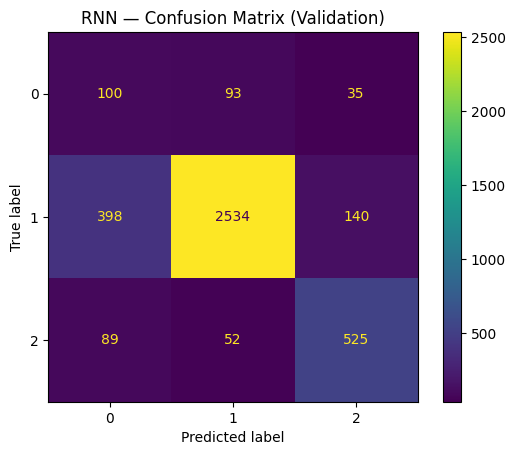

In [ ]:
evaluate_model(rnn_model, X_train_pad, y_train, X_val_pad, y_val, model_name="RNN")

# Training LSTM

In [ ]:
lstm_model = build_model("LSTM", lr=3e-4, dropout=0.2)
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Model: "LSTM_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)          │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,700,035 (10.30 MB)

 Trainable params: 2,700,035 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4524 - loss: 1.0959 - val_accuracy: 0.1679 - val_loss: 1.1072 - learning_rate: 3.0000e-04
Epoch 2/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3746 - loss: 1.0827 - val_accuracy: 0.1679 - val_loss: 1.0988 - learning_rate: 3.0000e-04
Epoch 3/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3071 - loss: 1.1009 - val_accuracy: 0.7746 - val_loss: 1.0693 - learning_rate: 3.0000e-04
Epoch 4/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5435 - loss: 1.0794 - val_accuracy: 0.8694 - val_loss: 0.6291 - learning_rate: 3.0000e-04
Epoch 5/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7770 - loss: 0.8120 - val_accuracy: 0.8664 - val_loss: 0.5836 - learning_rate: 3.0000e-04
Epoch 6/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7842 - loss: 0.6276 - val_accuracy: 0.8485 - val_loss: 0.5827 - learning_rate: 3.0000e-04
Epoch 7/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - acc

# LSTM Evaluation


========== LSTM ==========

--- TRAIN METRICS ---
Accuracy       : 0.9691677175283733
Macro F1       : 0.9167040891424773

--- VALIDATION METRICS ---
Accuracy       : 0.8724155320221886
Macro F1       : 0.6921292128446671

Validation Classification Report:

              precision    recall  f1-score   support

           0       0.36      0.34      0.35       228
           1       0.91      0.94      0.92      3072
           2       0.85      0.76      0.80       666

    accuracy                           0.87      3966
   macro avg       0.71      0.68      0.69      3966
weighted avg       0.87      0.87      0.87      3966

Validation Confusion Matrix:



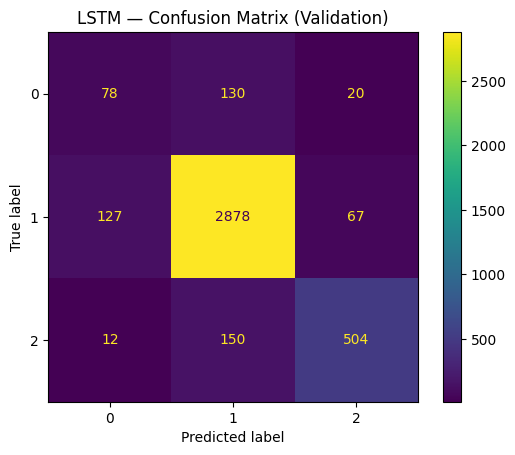

In [ ]:
evaluate_model(lstm_model, X_train_pad, y_train, X_val_pad, y_val, model_name="LSTM")

# Training & Evaluating GRU

Model: "GRU_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)          │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,523 (10.18 MB)

 Trainable params: 2,667,523 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.2965 - loss: 1.0870 - val_accuracy: 0.1679 - val_loss: 1.1043 - learning_rate: 1.0000e-04
Epoch 2/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2214 - loss: 1.0801 - val_accuracy: 0.0575 - val_loss: 1.1092 - learning_rate: 1.0000e-04
Epoch 3/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1765 - loss: 1.0913 - val_accuracy: 0.1679 - val_loss: 1.0982 - learning_rate: 1.0000e-04
Epoch 4/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3349 - loss: 1.0979 - val_accuracy: 0.0575 - val_loss: 1.0921 - learning_rate: 1.0000e-04
Epoch 5/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2540 - loss: 1.1024 - val_accuracy: 0.1679 - val_loss: 1.1043 - learning_rate: 1.0000e-04
Epoch 6/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2092 - loss: 1.0957 - val_accuracy: 0.0575 - val_loss: 1.1049 - learning_rate: 1.0000e-04
Epoch 7/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - acc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


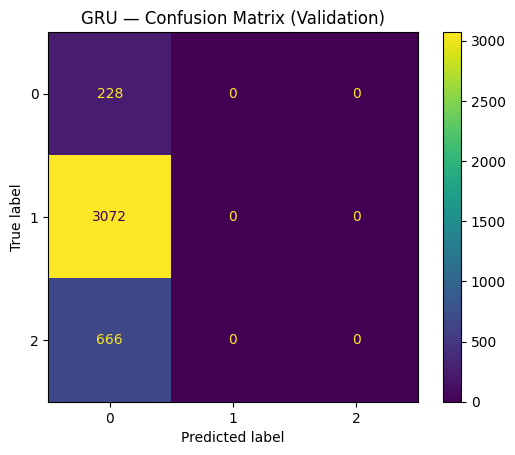

In [ ]:
gru_model = build_model("GRU", units=128, lr=1e-4, dropout=0.2)
gru_model.summary()

history_gru = gru_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)
evaluate_model(gru_model, X_train_pad, y_train, X_val_pad, y_val, model_name="GRU")

## Hypothesis: Why GRU Performed the Worst

The GRU likely collapsed during training and ended up predicting only one class.

This could be due to its sensitivity to the chosen hyperparameters (learning rate, dropout, class weights). Unlike LSTM, GRU has a simpler gating mechanism, and in this setup it may not have handled the imbalance and optimization dynamics as well. Therefore, I think that the weak performance is more likely due to optimization issues under the current configuration, rather than a limitation of the GRU model itself.

# Models Comparison
The best model was the LSTM.

In [ ]:
def get_val_preds(model):
    return np.argmax(model.predict(X_val_pad, verbose=0), axis=1)

pred_rnn  = get_val_preds(rnn_model)
pred_lstm = get_val_preds(lstm_model)
pred_gru  = get_val_preds(gru_model)

results_df = pd.DataFrame([
    {"Model":"RNN",  "Val_Accuracy": accuracy_score(y_val, pred_rnn),  "Val_F1_Macro": f1_score(y_val, pred_rnn, average="macro")},
    {"Model":"LSTM", "Val_Accuracy": accuracy_score(y_val, pred_lstm), "Val_F1_Macro": f1_score(y_val, pred_lstm, average="macro")},
    {"Model":"GRU",  "Val_Accuracy": accuracy_score(y_val, pred_gru),  "Val_F1_Macro": f1_score(y_val, pred_gru, average="macro")},
]).sort_values("Val_F1_Macro", ascending=False)

results_df

,Model,Val_Accuracy,Val_F1_Macro
1,LSTM,0.872416,0.692129
0,RNN,0.796520,0.631768
2,GRU,0.057489,0.036242


# Saving Submission File of the Best Model

In [ ]:
best_model = lstm_model
# 1) Predict
test_probs = best_model.predict(X_test_pad, verbose=0)
test_pred  = np.argmax(test_probs, axis=1)

# 2) Create an id column (0..n-1)
submission = pd.DataFrame({
    "id": np.arange(len(test_df)),
    "label": test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,label
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1


In [ ]:
# Path inside Google Drive
save_path = "/content/drive/MyDrive/Datasets/NLP/submission.csv"
submission.to_csv(save_path, index=False)
print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/Datasets/NLP/submission.csv


The LSTM model achieved strong performance on the unseen test set, reaching a Kaggle score of approximately 86.96%.

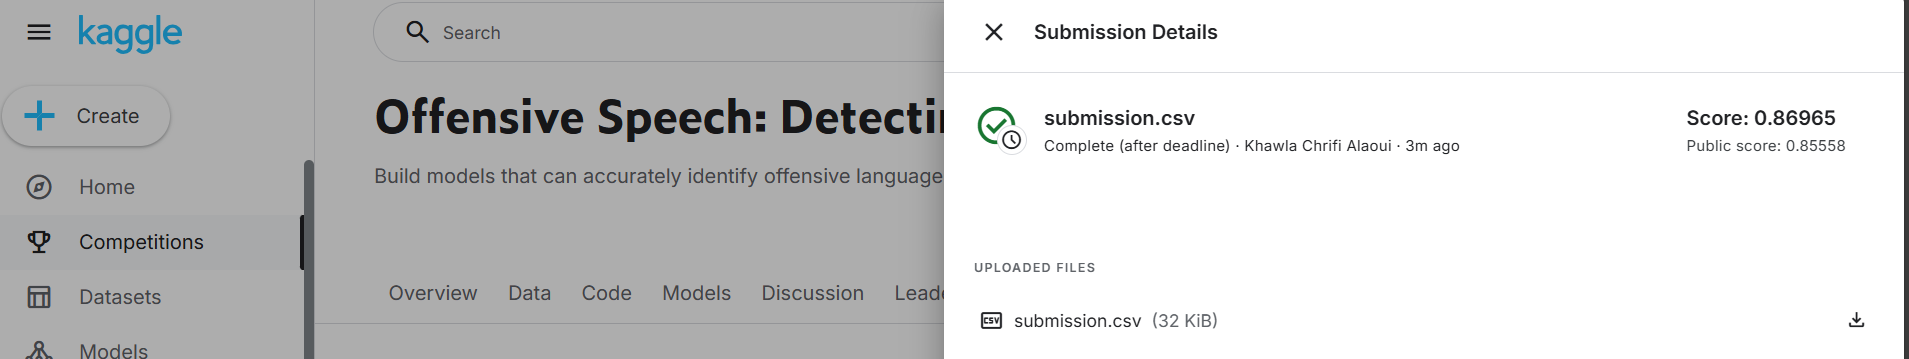

---

 *Realized by*  
**Khawla Chrifi Alaoui**

---